<a href="https://colab.research.google.com/github/Rogerio-mack/work/blob/main/Optimization_GA_SimulatedAnnealing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dados dos Ativos Simulados:
           Return  Volatility
Asset_1  0.106181    0.220223
Asset_2  0.192607    0.241615
Asset_3  0.159799    0.104117
Asset_4  0.139799    0.293982
Asset_5  0.073403    0.266489
Asset_6  0.073399    0.142468
Asset_7  0.058713    0.136365
Asset_8  0.179926    0.136681


Matriz de Correlação Simulada:
         Asset_1  Asset_2  Asset_3  Asset_4  Asset_5  Asset_6  Asset_7  \
Asset_1   1.0000   0.5655   0.4109   0.4164   0.1663   0.1834   0.2814   
Asset_2   0.5655   1.0000   0.2636   0.6265   0.6344   0.3123   0.2100   
Asset_3   0.4109   0.2636   1.0000   0.2473   0.5732   0.1522   0.4785   
Asset_4   0.4164   0.6265   0.2473   1.0000   0.5202   0.3867   0.5148   
Asset_5   0.1663   0.6344   0.5732   0.5202   1.0000   0.2069   0.5871   
Asset_6   0.1834   0.3123   0.1522   0.3867   0.2069   1.0000   0.4620   
Asset_7   0.2814   0.2100   0.4785   0.5148   0.5871   0.4620   1.0000   
Asset_8   0.3864   0.2138   0.2235   0.2488   0.3486   0.3374   0.6252   

  

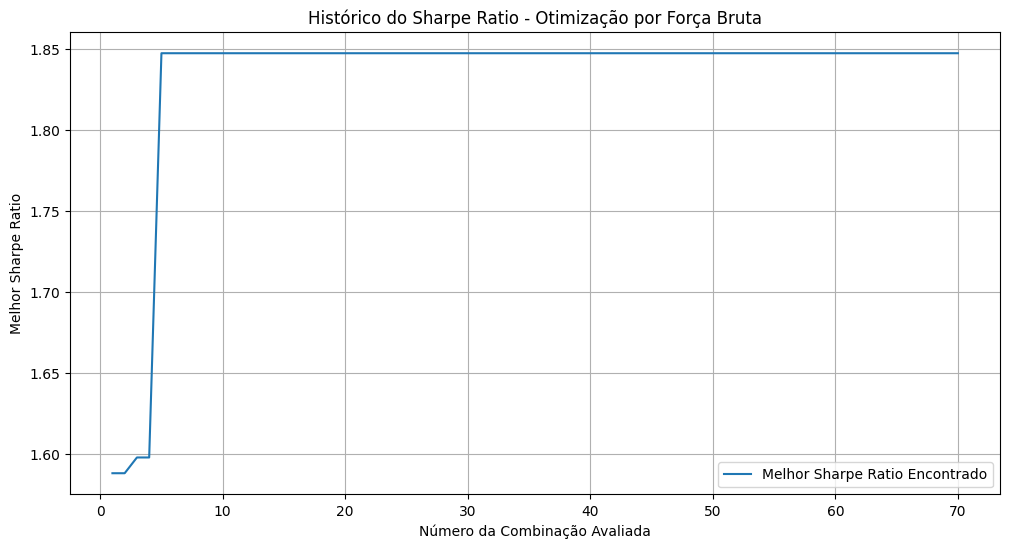

In [13]:
import numpy as np
import itertools
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Simulação de dados para 8 ativos (rentabilidade e volatilidade anualizadas)
np.random.seed(42) # Para reprodutibilidade

num_assets = 8
asset_names = [f'Asset_{i+1}' for i in range(num_assets)]

# Rentabilidades anuais (média e desvio padrão)
returns = np.random.uniform(0.05, 0.20, num_assets) # Entre 5% e 20%

# Volatividades anuais (média e desvio padrão)
volatilities = np.random.uniform(0.10, 0.30, num_assets) # Entre 10% e 30%

# Criar um DataFrame para melhor visualização
assets_df = pd.DataFrame({
    'Return': returns,
    'Volatility': volatilities
}, index=asset_names)

print("Dados dos Ativos Simulados:")
print(assets_df)
print("\n" + "="*50 + "\n")

# 2. Simulação da Matriz de Covariância
# Gerar uma matriz de correlação aleatória válida para simulação.
np.random.seed(42) # Reprodutibilidade para a matriz de correlação

# Gerar uma matriz aleatória e transformá-la em uma matriz de correlação válida
rand_mat = np.random.uniform(low=0.1, high=0.7, size=(num_assets, num_assets))
corr_matrix = (rand_mat + rand_mat.T) / 2 # Tornar simétrica
np.fill_diagonal(corr_matrix, 1.0) # Diagonais são 1

# Certificar que a matriz é positiva semi-definida (ajuste para eigenvalues negativos)
eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
if np.any(eigenvalues < 1e-6):
    eigenvalues[eigenvalues < 1e-6] = 1e-6 # Define um valor mínimo positivo
    corr_matrix = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    corr_matrix = corr_matrix / np.sqrt(np.diag(corr_matrix))[:, None]
    corr_matrix = corr_matrix / np.sqrt(np.diag(corr_matrix))[None, :]
    np.fill_diagonal(corr_matrix, 1.0) # Reafirma diagonal como 1

# Converter volatilidade para desvio padrão (já são anuais)
std_dev = np.diag(volatilities)

# Calcular a matriz de covariância
cov_matrix = std_dev @ corr_matrix @ std_dev

print("Matriz de Correlação Simulada:")
print(pd.DataFrame(corr_matrix, index=asset_names, columns=asset_names).round(4))
print("\nMatriz de Covariância Simulada:")
print(pd.DataFrame(cov_matrix, index=asset_names, columns=asset_names).round(4))
print("\n" + "="*50 + "\n")

# 3. Configurações para a otimização
num_assets_in_portfolio = 4

# Função objetivo (para maximizar o Sharpe Ratio, minimizamos o negativo do Sharpe Ratio)
def neg_sharpe_ratio(weights, returns_subset, cov_subset):
    portfolio_return = np.sum(returns_subset * weights)
    portfolio_volatility = np.sqrt(weights.T @ cov_subset @ weights)
    if portfolio_volatility == 0:
        return np.inf # Penaliza portfólios com volatilidade zero
    return -portfolio_return / portfolio_volatility

# 4. Otimização de Força Bruta com Otimização de Pesos
best_portfolio_assets = None
max_sharpe_ratio = -np.inf
best_portfolio_weights = None
best_portfolio_return = 0
best_portfolio_volatility = 0

all_combinations = list(itertools.combinations(range(num_assets), num_assets_in_portfolio)) # Usar índices de ativos

print(f"Total de combinações de ativos a serem avaliadas: {len(all_combinations)}")
print("Avaliando portfólios e otimizando pesos para cada combinação...\n")

# Histórico para o gráfico de Força Bruta
brute_force_sharpe_history = []

for combo_indices in all_combinations:
    # Extrair retornos e sub-matriz de covariância para os ativos selecionados
    returns_subset = assets_df['Return'].iloc[list(combo_indices)].values
    cov_subset = cov_matrix[np.ix_(list(combo_indices), list(combo_indices))]

    # Condições de otimização dos pesos
    num_selected_assets = len(combo_indices)
    initial_weights = np.array([1.0 / num_selected_assets] * num_selected_assets)
    bounds = tuple((0.0, 1.0) for _ in range(num_selected_assets))
    constraints = ({
        'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1
    })

    # Otimizar pesos para maximizar o Sharpe Ratio
    result = minimize(
        neg_sharpe_ratio,
        initial_weights,
        args=(returns_subset, cov_subset),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        current_weights = result.x
        current_sharpe_ratio = -result.fun # Reverter o negativo do Sharpe Ratio

        if current_sharpe_ratio > max_sharpe_ratio:
            max_sharpe_ratio = current_sharpe_ratio
            best_portfolio_assets = [asset_names[i] for i in combo_indices]
            best_portfolio_weights = current_weights
            # Recalcular Return e Volatility com os pesos otimizados
            best_portfolio_return = np.sum(returns_subset * current_weights)
            best_portfolio_volatility = np.sqrt(current_weights.T @ cov_subset @ current_weights)

    brute_force_sharpe_history.append(max_sharpe_ratio) # Armazena o melhor sharpe encontrado até agora

print("\n" + "="*50 + "\n")
print("Resultados da Otimização de Força Bruta (com Otimização de Pesos):")

if best_portfolio_assets:
    print(f"Melhor Composição de Portfólio (4 ativos): {tuple(best_portfolio_assets)}")
    print(f"Pesos do Portfólio: {[f'{w:.2%}' for w in best_portfolio_weights]}")
    print(f"Rentabilidade do Portfólio (Anualizada): {best_portfolio_return:.2%}")
    print(f"Volatilidade do Portfólio (Anualizada): {best_portfolio_volatility:.2%}")
    print(f"Sharpe Ratio (Otimizado): {max_sharpe_ratio:.4f}")

    print("\nDetalhes dos ativos no melhor portfólio:")
    best_portfolio_df = assets_df.loc[list(best_portfolio_assets)].copy()
    best_portfolio_df['Weight'] = best_portfolio_weights
    print(best_portfolio_df)
else:
    print("Nenhum portfólio ótimo foi encontrado pela Força Bruta.")

print("\n" + "="*50 + "\n")

# Plotar o histórico do Sharpe Ratio para Força Bruta
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(brute_force_sharpe_history) + 1), brute_force_sharpe_history, label='Melhor Sharpe Ratio Encontrado')
plt.xlabel('Número da Combinação Avaliada')
plt.ylabel('Melhor Sharpe Ratio')
plt.title('Histórico do Sharpe Ratio - Otimização por Força Bruta')
plt.grid(True)
plt.legend()
plt.show()



Iniciando Otimização de Portfólio com Algoritmo Genético (com Otimização de Pesos)...
Otimização concluída após 100 gerações.

Resultados do Algoritmo Genético (com Otimização de Pesos):
Melhor Composição de Portfólio (4 ativos): ('Asset_2', 'Asset_3', 'Asset_1', 'Asset_8')
Pesos do Portfólio: ['5.28%', '59.19%', '0.00%', '35.52%']
Rentabilidade do Portfólio (Anualizada): 16.87%
Volatilidade do Portfólio (Anualizada): 9.13%
Sharpe Ratio (Otimizado): 1.8475

Detalhes dos ativos no melhor portfólio (por Algoritmo Genético):
           Return  Volatility        Weight
Asset_2  0.192607    0.241615  5.284163e-02
Asset_3  0.159799    0.104117  5.919455e-01
Asset_1  0.106181    0.220223  1.326301e-15
Asset_8  0.179926    0.136681  3.552129e-01




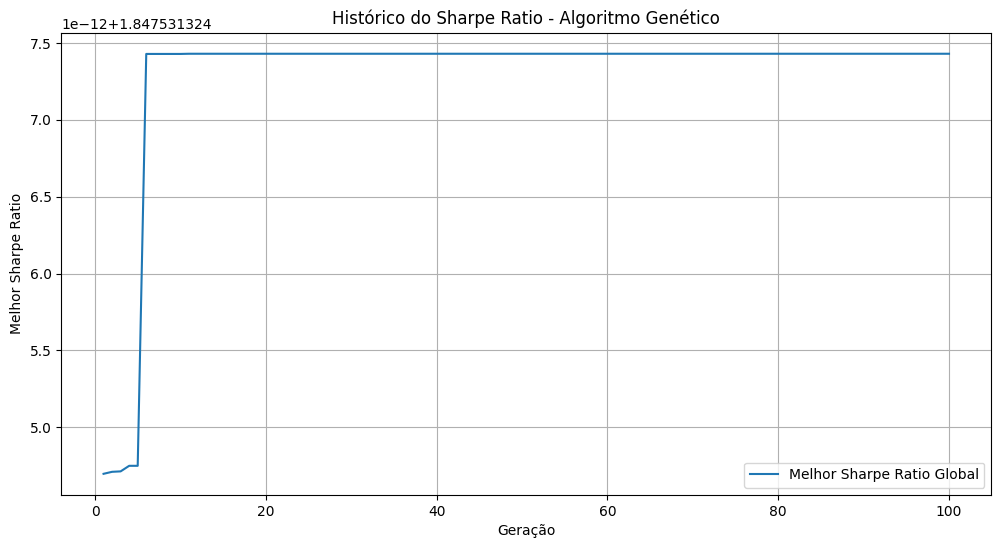

In [26]:
import numpy as np
import pandas as pd
import random
import itertools
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

# --- Parâmetros do Algoritmo Genético ---
POPULATION_SIZE = 50
NUM_GENERATIONS = 100
MUTATION_RATE = 0.1
ELITISM_RATE = 0.1 # Percentual da população que será copiada diretamente para a próxima geração
TOURNAMENT_SIZE = 5 # Para seleção por torneio

# As variáveis assets_df, num_assets, num_assets_in_portfolio e cov_matrix são do código anterior
# para garantir que estejam disponíveis, caso este cell seja executado isoladamente.
# Se esta célula for executada sozinha, irá gerar dados simulados e uma matriz de covariância.
# Check for critical variables' existence to ensure full setup if run standalone.
if 'assets_df' not in locals() or 'cov_matrix' not in locals() or 'asset_names' not in locals():
    np.random.seed(42)
    num_assets = 8
    asset_names = [f'Asset_{i+1}' for i in range(num_assets)]
    returns = np.random.uniform(0.05, 0.20, num_assets)
    volatilities = np.random.uniform(0.10, 0.30, num_assets)
    assets_df = pd.DataFrame({
        'Return': returns,
        'Volatility': volatilities
    }, index=asset_names)
    num_assets_in_portfolio = 4

    # Gerar matriz de covariância para execução standalone
    rand_mat = np.random.uniform(low=0.1, high=0.7, size=(num_assets, num_assets))
    corr_matrix = (rand_mat + rand_mat.T) / 2
    np.fill_diagonal(corr_matrix, 1.0)

    eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
    if np.any(eigenvalues < 1e-6):
        eigenvalues[eigenvalues < 1e-6] = 1e-6
        corr_matrix = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
        corr_matrix = corr_matrix / np.sqrt(np.diag(corr_matrix))[:, None]
        corr_matrix = corr_matrix / np.sqrt(np.diag(corr_matrix))[None, :]
        np.fill_diagonal(corr_matrix, 1.0)

    std_dev = np.diag(volatilities)
    cov_matrix = std_dev @ corr_matrix @ std_dev

# Função objetivo (para maximizar o Sharpe Ratio, minimizamos o negativo do Sharpe Ratio)
def neg_sharpe_ratio_ga(weights, returns_subset, cov_subset):
    portfolio_return = np.sum(returns_subset * weights)
    portfolio_volatility = np.sqrt(weights.T @ cov_subset @ weights)
    if portfolio_volatility == 0 or np.isnan(portfolio_volatility):
        return np.inf # Penaliza portfólios com volatilidade zero ou NaN
    return -portfolio_return / portfolio_volatility

# --- Funções do Algoritmo Genético ---

# 1. Função de Avaliação (Fitness) - AGORA COM OTIMIZAÇÃO DE PESOS
def calculate_portfolio_metrics_optimized_weights(selected_asset_indices):
    if not selected_asset_indices:
        return 0, 0, 0, [] # Return 0 for empty portfolio, empty weights

    # Extrair retornos e sub-matriz de covariância para os ativos selecionados
    returns_subset = assets_df['Return'].iloc[list(selected_asset_indices)].values
    cov_subset = cov_matrix[np.ix_(list(selected_asset_indices), list(selected_asset_indices))]

    # Condições de otimização dos pesos
    num_selected_assets = len(selected_asset_indices)
    initial_weights = np.array([1.0 / num_selected_assets] * num_selected_assets)
    bounds = tuple((0.0, 1.0) for _ in range(num_selected_assets))
    constraints = ({
        'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1
    })

    # Otimizar pesos para maximizar o Sharpe Ratio
    result = minimize(
        neg_sharpe_ratio_ga,
        initial_weights,
        args=(returns_subset, cov_subset),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        optimized_weights = result.x
        portfolio_return = np.sum(returns_subset * optimized_weights)
        portfolio_volatility = np.sqrt(optimized_weights.T @ cov_subset @ optimized_weights)
        sharpe_ratio = -result.fun
    else:
        # Fallback if optimization fails (e.g., return very low Sharpe)
        portfolio_return = 0
        portfolio_volatility = np.inf
        sharpe_ratio = -np.inf
        optimized_weights = [0.0] * num_selected_assets

    return portfolio_return, portfolio_volatility, sharpe_ratio, optimized_weights

# 2. Inicialização da População (inalterada, ainda seleciona índices de ativos)
def initialize_population(pop_size, total_assets, assets_in_portfolio):
    population = []
    for _ in range(pop_size):
        individual = random.sample(range(total_assets), assets_in_portfolio)
        population.append(individual)
    return population

# 3. Seleção (Torneio) (inalterada)
def tournament_selection(population, fitnesses, tournament_size):
    selected_parent = None
    best_fitness = -np.inf

    for _ in range(tournament_size):
        idx = random.randint(0, len(population) - 1)
        if fitnesses[idx] > best_fitness:
            best_fitness = fitnesses[idx]
            selected_parent = population[idx]
    return selected_parent

# 4. Crossover (Recombinação) (inalterada)
def crossover(parent1, parent2, total_assets, assets_in_portfolio):
    combined_assets = list(set(parent1 + parent2))
    if len(combined_assets) < assets_in_portfolio:
        remaining_assets = [i for i in range(total_assets) if i not in combined_assets]
        fill_count = assets_in_portfolio - len(combined_assets)
        combined_assets.extend(random.sample(remaining_assets, fill_count))
    offspring = random.sample(combined_assets, assets_in_portfolio)
    return offspring

# 5. Mutação (inalterada)
def mutate(individual, total_assets, assets_in_portfolio):
    mutated_individual = list(individual) # Cópia para não modificar o original
    if random.random() < MUTATION_RATE:
        asset_to_remove_idx = random.randint(0, assets_in_portfolio - 1)
        asset_to_remove = mutated_individual[asset_to_remove_idx]

        available_assets = [i for i in range(total_assets) if i not in mutated_individual]
        if available_assets:
            asset_to_add = random.choice(available_assets)
            mutated_individual[asset_to_remove_idx] = asset_to_add
    return mutated_individual

# --- Execução do Algoritmo Genético ---

print("\n" + "="*50 + "\n")
print("Iniciando Otimização de Portfólio com Algoritmo Genético (com Otimização de Pesos)...")

# 1. Inicializa a população
population = initialize_population(POPULATION_SIZE, num_assets, num_assets_in_portfolio)

best_portfolio_overall_indices = None
max_sharpe_ratio_overall = -np.inf
best_return_overall = 0
best_volatility_overall = 0
best_weights_overall = None

ga_sharpe_history = [] # Histórico para o gráfico do Algoritmo Genético

for generation in range(NUM_GENERATIONS):
    # Avalia a população
    fitnesses = []
    portfolio_details = [] # Para armazenar retorno, volatilidade, sharpe, e pesos
    for individual in population:
        ret, vol, sharpe, weights = calculate_portfolio_metrics_optimized_weights(individual)
        fitnesses.append(sharpe)
        portfolio_details.append({'return': ret, 'volatility': vol, 'sharpe': sharpe, 'weights': weights})

    # Encontra o melhor indivíduo da geração
    if not fitnesses: # Handle case of empty fitnesses if all optimizations fail
        ga_sharpe_history.append(max_sharpe_ratio_overall) # Store previous best if no new valid fitness
        continue
    best_gen_idx = np.argmax(fitnesses)
    current_best_sharpe = fitnesses[best_gen_idx]
    current_best_individual_indices = population[best_gen_idx]

    if current_best_sharpe > max_sharpe_ratio_overall:
        max_sharpe_ratio_overall = current_best_sharpe
        best_portfolio_overall_indices = current_best_individual_indices
        best_return_overall = portfolio_details[best_gen_idx]['return']
        best_volatility_overall = portfolio_details[best_gen_idx]['volatility']
        best_weights_overall = portfolio_details[best_gen_idx]['weights']

    ga_sharpe_history.append(max_sharpe_ratio_overall) # Armazena o melhor sharpe encontrado até agora na geração

    # Ordena a população por fitness (para elitismo)
    sorted_population_indices = np.argsort(fitnesses)[::-1] # Decrescente
    sorted_population = [population[i] for i in sorted_population_indices]
    sorted_fitnesses = [fitnesses[i] for i in sorted_population_indices]

    new_population = []

    # Elitismo: Copia os melhores indivíduos diretamente
    num_elitism = int(POPULATION_SIZE * ELITISM_RATE)
    new_population.extend(sorted_population[:num_elitism])

    # Gera a nova população através de seleção, crossover e mutação
    while len(new_population) < POPULATION_SIZE:
        parent1 = tournament_selection(population, sorted_fitnesses, TOURNAMENT_SIZE)
        parent2 = tournament_selection(population, sorted_fitnesses, TOURNAMENT_SIZE)

        offspring = crossover(parent1, parent2, num_assets, num_assets_in_portfolio)
        offspring = mutate(offspring, num_assets, num_assets_in_portfolio)
        new_population.append(offspring)

    population = new_population

print(f"Otimização concluída após {NUM_GENERATIONS} gerações.\n")
print("Resultados do Algoritmo Genético (com Otimização de Pesos):")

if best_portfolio_overall_indices is not None:
    best_asset_names = [asset_names[i] for i in best_portfolio_overall_indices]
    print(f"Melhor Composição de Portfólio (4 ativos): {tuple(best_asset_names)}")
    print(f"Pesos do Portfólio: {[f'{w:.2%}' for w in best_weights_overall]}")
    print(f"Rentabilidade do Portfólio (Anualizada): {best_return_overall:.2%}")
    print(f"Volatilidade do Portfólio (Anualizada): {best_volatility_overall:.2%}")
    print(f"Sharpe Ratio (Otimizado): {max_sharpe_ratio_overall:.4f}")

    print("\nDetalhes dos ativos no melhor portfólio (por Algoritmo Genético):")
    best_portfolio_df_ga = assets_df.loc[list(best_asset_names)].copy()
    best_portfolio_df_ga['Weight'] = best_weights_overall
    print(best_portfolio_df_ga)
else:
    print("Nenhum portfólio válido foi encontrado pelo Algoritmo Genético.")

print("\n" + "="*50 + "\n")

# Plotar o histórico do Sharpe Ratio para o Algoritmo Genético
plt.figure(figsize=(12, 6))
plt.plot(range(1, NUM_GENERATIONS + 1), ga_sharpe_history, label='Melhor Sharpe Ratio Global')
plt.xlabel('Geração')
plt.ylabel('Melhor Sharpe Ratio')
plt.title('Histórico do Sharpe Ratio - Algoritmo Genético')
plt.grid(True)
plt.legend()
plt.show()

In [11]:
best_portfolio_df_ga.Weight.sum()

np.float64(1.0)

### Otimização de Portfólio com Simulated Annealing (com Otimização de Pesos)



Iniciando Otimização de Portfólio com Simulated Annealing (com Otimização de Pesos)...
Otimização concluída após o resfriamento. Temperatura final: 1.00e-05

Resultados do Simulated Annealing (com Otimização de Pesos):
Melhor Composição de Portfólio (4 ativos): ('Asset_1', 'Asset_2', 'Asset_3', 'Asset_8')
Pesos do Portfólio: ['0.00%', '5.28%', '59.19%', '35.52%']
Rentabilidade do Portfólio (Anualizada): 16.87%
Volatilidade do Portfólio (Anualizada): 9.13%
Sharpe Ratio (Otimizado): 1.8475

Detalhes dos ativos no melhor portfólio (por Simulated Annealing):
           Return  Volatility    Weight
Asset_1  0.106181    0.220223  0.000000
Asset_2  0.192607    0.241615  0.052842
Asset_3  0.159799    0.104117  0.591945
Asset_8  0.179926    0.136681  0.355213




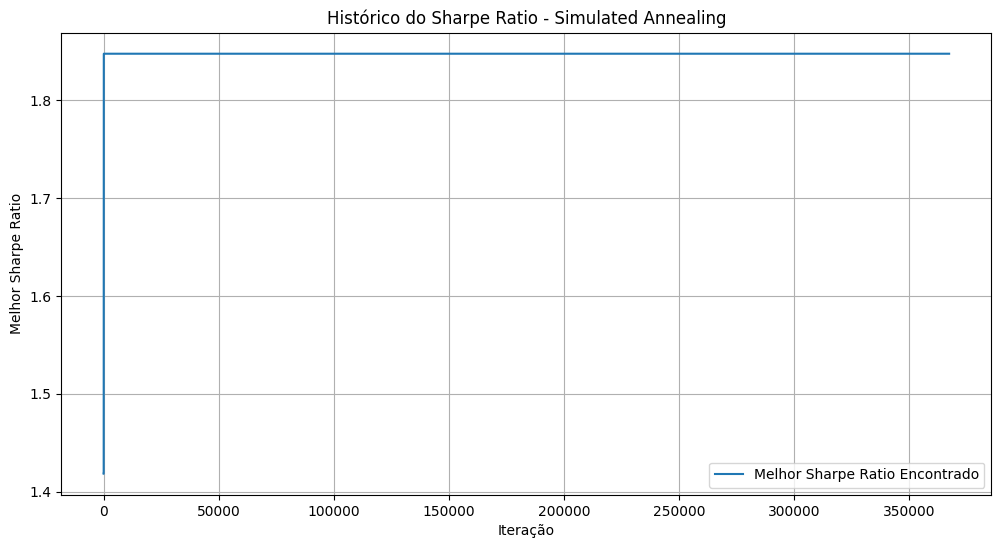

In [15]:
import numpy as np
import random
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

# --- Parâmetros do Simulated Annealing ---
INITIAL_TEMPERATURE = 1000.0 # Temperatura inicial
COOLING_RATE = 0.995       # Taxa de resfriamento (entre 0 e 1)
MIN_TEMPERATURE = 1.0e-5   # Temperatura mínima para parar
NUM_ITERATIONS_AT_TEMP = 100 # Número de iterações em cada temperatura

# Re-definir a função objetivo para garantir que esteja disponível
def neg_sharpe_ratio_sa(weights, returns_subset, cov_subset):
    portfolio_return = np.sum(returns_subset * weights)
    portfolio_volatility = np.sqrt(weights.T @ cov_subset @ weights)
    if portfolio_volatility == 0 or np.isnan(portfolio_volatility):
        return np.inf # Penaliza portfólios com volatilidade zero ou NaN
    return -portfolio_return / portfolio_volatility

# Função para calcular métricas de portfólio com pesos otimizados
def calculate_portfolio_metrics_optimized_weights_sa(selected_asset_indices):
    if not selected_asset_indices:
        return 0, 0, 0, [] # Return 0 for empty portfolio, empty weights

    returns_subset = assets_df['Return'].iloc[list(selected_asset_indices)].values
    cov_subset = cov_matrix[np.ix_(list(selected_asset_indices), list(selected_asset_indices))]

    num_selected_assets = len(selected_asset_indices)
    initial_weights = np.array([1.0 / num_selected_assets] * num_selected_assets)
    bounds = tuple((0.0, 1.0) for _ in range(num_selected_assets))
    constraints = ({
        'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1
    })

    result = minimize(
        neg_sharpe_ratio_sa,
        initial_weights,
        args=(returns_subset, cov_subset),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        optimized_weights = result.x
        portfolio_return = np.sum(returns_subset * optimized_weights)
        portfolio_volatility = np.sqrt(optimized_weights.T @ cov_subset @ optimized_weights)
        sharpe_ratio = -result.fun
    else:
        portfolio_return = 0
        portfolio_volatility = np.inf
        sharpe_ratio = -np.inf
        optimized_weights = [0.0] * num_selected_assets

    return portfolio_return, portfolio_volatility, sharpe_ratio, optimized_weights

# Função para gerar um vizinho (alterar um ativo no portfólio)
def generate_neighbor(current_solution, num_assets, num_assets_in_portfolio):
    neighbor = list(current_solution) # Make a mutable copy

    # Select an asset to remove from the current portfolio
    asset_to_remove_idx = random.randint(0, num_assets_in_portfolio - 1)
    asset_to_remove = neighbor[asset_to_remove_idx]

    # Select a new asset to add that is not currently in the portfolio
    available_assets = [i for i in range(num_assets) if i not in neighbor]

    if available_assets: # Only proceed if there are assets to add
        asset_to_add = random.choice(available_assets)
        neighbor[asset_to_remove_idx] = asset_to_add

    # Ensure the neighbor has unique assets (in case random choices lead to duplicates after a swap)
    # This can happen if the 'asset_to_add' was already present due to some edge cases in `random.choice` if not careful
    # Or if a duplicated asset was initially in `current_solution` (which shouldn't happen with `random.sample`)
    # The set conversion handles this by ensuring uniqueness
    neighbor = list(set(neighbor))

    # If the neighbor somehow lost assets due to set conversion (shouldn't happen with valid swaps),
    # refill it to the required size
    while len(neighbor) < num_assets_in_portfolio:
        all_available = set(range(num_assets)) - set(neighbor)
        if not all_available:
            break # No more assets to add
        neighbor.append(random.choice(list(all_available)))

    return tuple(sorted(neighbor))


# --- Execução do Simulated Annealing ---

print("\n" + "="*50 + "\n")
print("Iniciando Otimização de Portfólio com Simulated Annealing (com Otimização de Pesos)...")

# 1. Solução inicial aleatória
current_solution_indices = tuple(random.sample(range(num_assets), num_assets_in_portfolio))
current_return, current_volatility, current_sharpe, current_weights = calculate_portfolio_metrics_optimized_weights_sa(current_solution_indices)

best_solution_indices = current_solution_indices
best_sharpe = current_sharpe
best_return = current_return
best_volatility = current_volatility
best_weights = current_weights

temperature = INITIAL_TEMPERATURE

sa_sharpe_history = [] # Histórico para o gráfico de Simulated Annealing

while temperature > MIN_TEMPERATURE:
    for _ in range(NUM_ITERATIONS_AT_TEMP):
        neighbor_solution_indices = generate_neighbor(current_solution_indices, num_assets, num_assets_in_portfolio)

        # Certifique-se de que o vizinho tem o número correto de ativos
        if len(neighbor_solution_indices) != num_assets_in_portfolio:
            sa_sharpe_history.append(best_sharpe) # Store current best if neighbor is invalid
            continue # Skip invalid neighbors

        neighbor_return, neighbor_volatility, neighbor_sharpe, neighbor_weights = calculate_portfolio_metrics_optimized_weights_sa(neighbor_solution_indices)

        # Calcula a mudança de energia (Sharpe Ratio, estamos maximizando, então -sharpe é a "energia")
        delta_sharpe = neighbor_sharpe - current_sharpe

        # Se o vizinho é melhor, aceita
        if delta_sharpe > 0:
            current_solution_indices = neighbor_solution_indices
            current_sharpe = neighbor_sharpe
            current_return = neighbor_return
            current_volatility = neighbor_volatility
            current_weights = neighbor_weights

            if current_sharpe > best_sharpe:
                best_sharpe = current_sharpe
                best_solution_indices = current_solution_indices
                best_return = current_return
                best_volatility = current_volatility
                best_weights = current_weights
        else:
            # Se o vizinho é pior, aceita com uma probabilidade
            acceptance_probability = np.exp(delta_sharpe / temperature) # delta_sharpe é negativo aqui
            if random.random() < acceptance_probability:
                current_solution_indices = neighbor_solution_indices
                current_sharpe = neighbor_sharpe
                current_return = neighbor_return
                current_volatility = neighbor_volatility
                current_weights = neighbor_weights

        sa_sharpe_history.append(best_sharpe) # Armazena o melhor sharpe encontrado até agora

    temperature *= COOLING_RATE # Resfria o sistema

print(f"Otimização concluída após o resfriamento. Temperatura final: {temperature:.2e}\n")
print("Resultados do Simulated Annealing (com Otimização de Pesos):")

if best_solution_indices is not None:
    best_asset_names_sa = [asset_names[i] for i in best_solution_indices]
    print(f"Melhor Composição de Portfólio (4 ativos): {tuple(best_asset_names_sa)}")
    print(f"Pesos do Portfólio: {[f'{w:.2%}' for w in best_weights]}")
    print(f"Rentabilidade do Portfólio (Anualizada): {best_return:.2%}")
    print(f"Volatilidade do Portfólio (Anualizada): {best_volatility:.2%}")
    print(f"Sharpe Ratio (Otimizado): {best_sharpe:.4f}")

    print("\nDetalhes dos ativos no melhor portfólio (por Simulated Annealing):")
    best_portfolio_df_sa = assets_df.loc[list(best_asset_names_sa)].copy()
    best_portfolio_df_sa['Weight'] = best_weights
    print(best_portfolio_df_sa)
else:
    print("Nenhum portfólio válido foi encontrado pelo Simulated Annealing.")

print("\n" + "="*50 + "\n")

# Plotar o histórico do Sharpe Ratio para Simulated Annealing
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(sa_sharpe_history) + 1), sa_sharpe_history, label='Melhor Sharpe Ratio Encontrado')
plt.xlabel('Iteração')
plt.ylabel('Melhor Sharpe Ratio')
plt.title('Histórico do Sharpe Ratio - Simulated Annealing')
plt.grid(True)
plt.legend()
plt.show()

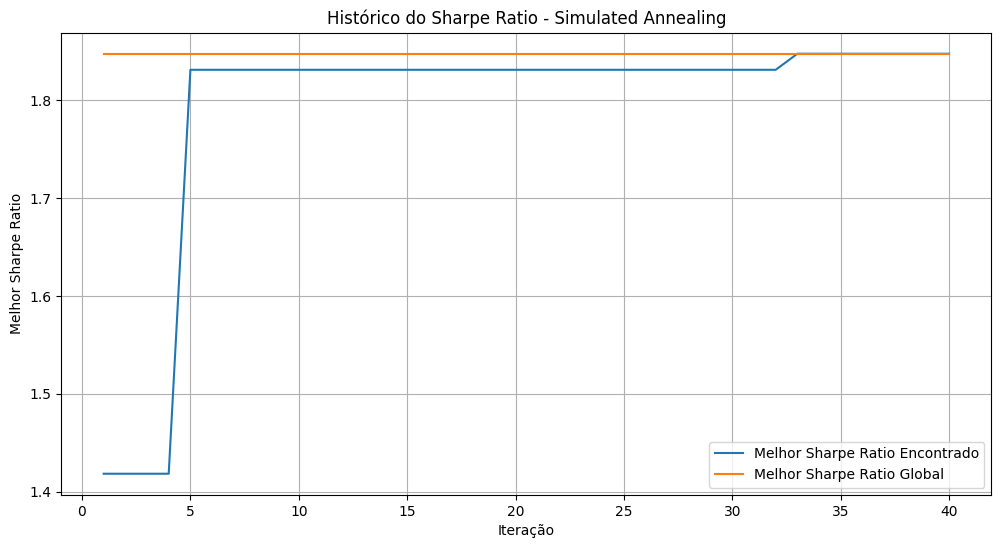

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(sa_sharpe_history[0:40]) + 1), sa_sharpe_history[0:40], label='Melhor Sharpe Ratio Encontrado')
plt.plot(range(1, len(ga_sharpe_history[0:40]) + 1), ga_sharpe_history[0:40], label='Melhor Sharpe Ratio Global')
plt.xlabel('Iteração')
plt.ylabel('Melhor Sharpe Ratio')
plt.title('Histórico do Sharpe Ratio - Simulated Annealing')
plt.grid(True)
plt.legend()
plt.show()